# Are geo-lift tools interchangeable? A calibration study
### Iteration 5 · benchmarking estimators on the label's geo experiments

Iteration 3 used **one** geo experiment to measure ad incrementality, picking estimators
somewhat arbitrarily. But a recent **Recast** Monte-Carlo study
([research.getrecast.com/geolift-sim-study](https://research.getrecast.com/geolift-sim-study/),
[code](https://github.com/getrecast/geolift-simulation-study)) benchmarked four popular
geo-lift tools — **Meta GeoLift**, **CausalPy**, **Google Matched Markets**, and **Google
CausalImpact** — across **32,000 simulations** and found they are **not interchangeable**:
under stress they differ sharply in **false-positive rate, coverage, and power**.

This notebook **replicates that methodology on our music-streaming case**: simulate the
label's geo experiments many times, inject a *known* lift (or none), and measure how each
estimator behaves. The lesson: **the inference method, not just the point estimate,
decides whether you can trust a geo test.**

### Tools (what we run here vs. what we cite)
| Recast tool | Method | Here |
|---|---|---|
| Google Matched Markets | Time-Based Regression (OLS) | **TBR** (from scratch) |
| Meta GeoLift | Augmented SC + conformal | **Synthetic Control** + placebo (SC core) |
| CausalPy | Bayesian SC | **CausalPy** (run directly) |
| Google CausalImpact | BSTS | *cited* (R-only; not run) |
| — | TWFE baseline | **DiD** (cluster-robust) |

> GeoLift and CausalImpact are R packages and R isn't available in this environment, so we
> map GeoLift to its synthetic-control core and document CausalImpact. The point is the
> **calibration methodology**, which transfers to any tool.

### Metrics (per Recast's "equalization protocol", all at 95%)
- **False-positive rate (FPR)** — reject H₀ when true lift = 0 (should be ~5%).
- **Power** — reject H₀ when true lift = +10% (higher is better).
- **Coverage** — 95% CI contains the true lift (should be ~95%).
- **Bias** — mean(estimate − truth).


## 1 · Setup

In [1]:
import warnings; warnings.filterwarnings("ignore"); import logging; logging.disable(logging.WARNING)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize":(11,4.5),"figure.dpi":110,"axes.grid":True,"grid.alpha":.25,
    "axes.spines.top":False,"axes.spines.right":False,"font.size":11})
BLUE,RED,GREEN,GREY,GOLD="#3b6fb0","#d1495b","#66a182","#9e9e9e","#e8a33d"
TOOLCOL={"DiD":GOLD,"TBR":RED,"SC":GREEN,"CausalPy":BLUE}

## 2 · DGP — geo panel for one flagship single

Following Recast's generator: **log-normal** geo baselines, a **shared trend**, **weekly
seasonality**, and **AR(1)** autocorrelated noise (the feature that breaks naive inference).
Geo 0 is treated; its post-period streams are multiplied by `(1+τ)`.

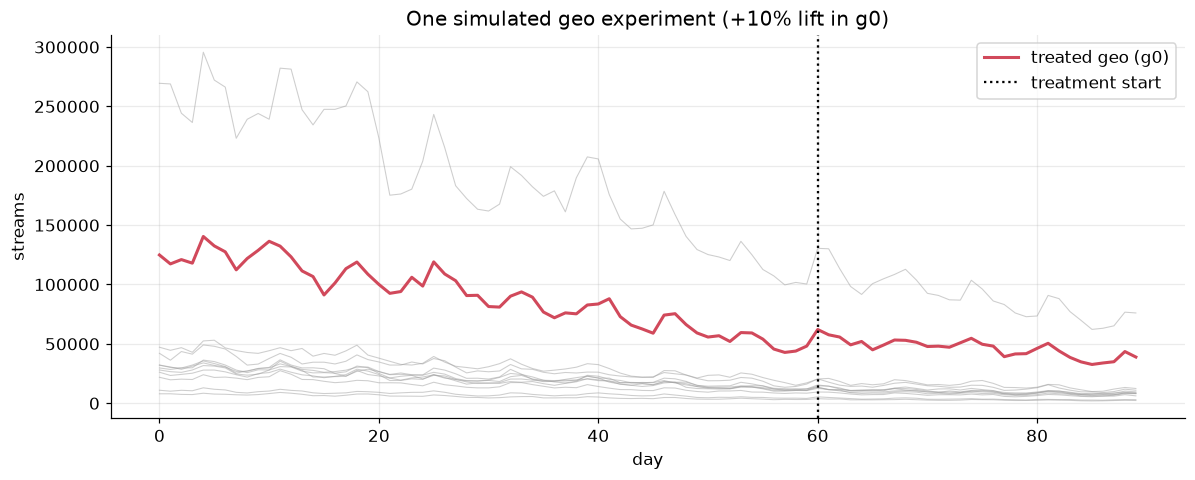

In [2]:
def sim_panel(rng, G=12, Tpre=60, Tpost=30, tau=0.0, outlier=False):
    T=Tpre+Tpost; t=np.arange(T)
    base=np.exp(rng.normal(np.log(40000),0.6,G))
    if outlier: base[0]*=5
    decay=np.exp(-np.log(2)/45*t)
    weekly=np.array([.95,.93,.95,1,1.18,1.14,1.06]); weekly=weekly/weekly.mean()
    shared=np.cumsum(rng.normal(0,0.02,T))
    Y=np.zeros((G,T))
    for g in range(G):
        ar=np.zeros(T)
        for k in range(1,T): ar[k]=0.6*ar[k-1]+rng.normal(0,0.05)
        Y[g]=base[g]*decay*weekly[t%7]*np.exp(shared+ar)
    Y[0,Tpre:]*=(1+tau)
    cols=[f"g{g}" for g in range(G)]
    df=pd.DataFrame(Y.T,columns=cols); df["t"]=t; df["post"]=(t>=Tpre).astype(int)
    return df, cols, Tpre, tau

# illustrate one draw
df0,cols0,Tpre0,_=sim_panel(np.random.default_rng(3),tau=0.10)
fig,ax=plt.subplots()
for c in cols0[1:]: ax.plot(df0.t, df0[c], color=GREY, lw=.7, alpha=.5)
ax.plot(df0.t, df0["g0"], color=RED, lw=2, label="treated geo (g0)")
ax.axvline(Tpre0,color="k",ls=":",label="treatment start")
ax.set_title("One simulated geo experiment (+10% lift in g0)"); ax.set_xlabel("day"); ax.set_ylabel("streams"); ax.legend()
plt.tight_layout(); plt.show()

## 3 · The estimators

Each returns **(lift%, CI low, CI high)**. They differ mainly in **how they do inference**:
- **DiD** — TWFE, cluster-robust SE by geo (a single treated cluster → known to be
  anti-conservative).
- **TBR** (≈ Google Matched Markets) — OLS counterfactual from controls; Gaussian
  prediction interval that **ignores autocorrelation**.
- **SC** (≈ GeoLift's core) — synthetic control with **in-space placebo** inference
  (design-based; robust but can be conservative).
- **CausalPy** — Bayesian SC; posterior 95% credible interval.

In [3]:
import pyfixest as pf
from pysyncon import Dataprep, Synth
import causalpy as cp

def est_did(df,cols,Tpre):
    long=df.melt(id_vars=["t","post"],value_vars=cols,var_name="geo",value_name="y")
    long["ly"]=np.log(long.y); long["tp"]=(long.geo=="g0").astype(int)*long.post
    m=pf.feols("ly ~ tp | geo + t", long, vcov={"CRV1":"geo"})
    b,se=m.coef()["tp"],m.se()["tp"]; return np.expm1(b),np.expm1(b-1.96*se),np.expm1(b+1.96*se)

def est_tbr(df,cols,Tpre):
    y=df["g0"].values; x=df[cols[1:]].sum(1).values; pre=slice(0,Tpre); post=slice(Tpre,None)
    A=np.vstack([np.ones(Tpre),x[pre]]).T; coef,_,_,_=np.linalg.lstsq(A,y[pre],rcond=None)
    sig=(y[pre]-A@coef).std(ddof=2); cf=coef[0]+coef[1]*x[post]; cum=(y[post]-cf).sum()
    se=sig*np.sqrt(len(cf)); cf_sum=cf.sum()
    return cum/cf_sum,(cum-1.96*se)/cf_sum,(cum+1.96*se)/cf_sum

def _sc_gap(df,treat,donors,Tpre):
    long=df.melt(id_vars=["t"],value_vars=[treat]+donors,var_name="geo",value_name="y")
    dp=Dataprep(foo=long,predictors=["y"],predictors_op="mean",dependent="y",unit_variable="geo",
        time_variable="t",treatment_identifier=treat,controls_identifier=donors,
        time_predictors_prior=list(range(Tpre)),time_optimize_ssr=list(range(Tpre)))
    s=Synth(); s.fit(dataprep=dp); wide=df.set_index("t"); synth=wide[donors]@s.W
    return (wide[treat]-synth).iloc[Tpre:].sum()/synth.iloc[Tpre:].sum()
def est_sc(df,cols,Tpre):
    eff=_sc_gap(df,"g0",cols[1:],Tpre)
    plac=[]
    for d in cols[1:]:
        try: plac.append(_sc_gap(df,d,[c for c in cols if c!=d],Tpre))
        except Exception: pass
    sd=np.std(plac) if len(plac)>1 else abs(eff); return eff,eff-1.96*sd,eff+1.96*sd

def est_causalpy(df,cols,Tpre,draws=300):
    cpdf=df.set_index("t")[cols]
    r=cp.SyntheticControl(cpdf,Tpre,control_units=cols[1:],treated_units=["g0"],
        model=cp.pymc_models.WeightedSumFitter(sample_kwargs=dict(draws=draws,tune=draws,
            chains=2,cores=1,progressbar=False,random_seed=int(abs(df['g0'].iloc[0]))%9999)))
    post=r.post_impact.sum(dim="obs_ind").stack(s=("chain","draw")).values.ravel()
    cf=r.post_pred["posterior_predictive"].mu.sum(dim="obs_ind").stack(s=("chain","draw")).values.ravel()
    lift=post/cf; return float(np.mean(lift)),float(np.percentile(lift,2.5)),float(np.percentile(lift,97.5))
print("estimators ready")

estimators ready


## 4 · Monte-Carlo sweep

Three **stress scenarios** × two **effect conditions** (0% and +10%), many simulations each.
For each we record reject / cover. (CausalPy is Bayesian and slow, so it's run on the
textbook scenario with fewer iterations — enough to read its calibration.)

In [4]:
SCENARIOS={"Textbook":dict(G=12,Tpre=60),"Small donor pool":dict(G=6,Tpre=60),
           "Short pre-period":dict(G=12,Tpre=21)}
N=80; rows=[]
import sys
for sc,par in SCENARIOS.items():
    for tau in [0.0,0.10]:
        for s in range(N):
            rng=np.random.default_rng(hash((sc,tau,s))%(2**32))
            df,cols,Tpre,true=sim_panel(rng,tau=tau,**par)
            for nm,fn in [("DiD",est_did),("TBR",est_tbr),("SC",est_sc)]:
                try:
                    e,lo,hi=fn(df,cols,Tpre)
                    rows.append((sc,tau,nm,e,int(lo>0 or hi<0),int(lo<=true<=hi)))
                except Exception: pass
        print(f"  done {sc} tau={tau:.0%}", flush=True)
res_fast=pd.DataFrame(rows,columns=["scenario","tau","tool","est","reject","cover"])
print("fast-tool sims collected:", len(res_fast))

  done Textbook tau=0%


  done Textbook tau=10%


  done Small donor pool tau=0%


  done Small donor pool tau=10%


  done Short pre-period tau=0%


  done Short pre-period tau=10%


fast-tool sims collected: 1440


### CausalPy (Bayesian) — textbook scenario only

CausalPy refits a PyMC model per simulation, so it's slow; we run a smaller number of
iterations on the textbook scenario — enough to read its calibration alongside the others.

In [5]:
cp_rows=[]
for tau in [0.0,0.10]:
    for s in range(12):
        rng=np.random.default_rng(hash(("cp",tau,s))%(2**32))
        df,cols,Tpre,true=sim_panel(rng,tau=tau,**SCENARIOS["Textbook"])
        try:
            e,lo,hi=est_causalpy(df,cols,Tpre,draws=200)
            cp_rows.append(("Textbook",tau,"CausalPy",e,int(lo>0 or hi<0),int(lo<=true<=hi)))
        except Exception: pass
    print(f"  done CausalPy tau={tau:.0%}", flush=True)
res=pd.concat([res_fast,pd.DataFrame(cp_rows,columns=res_fast.columns)],ignore_index=True)
print("total sims collected:", len(res))

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


...

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  done CausalPy tau=10%


total sims collected: 1464


## 5 · Results

In [6]:
def agg(scn):
    d=res[res.scenario==scn]
    out=[]
    for nm in ["DiD","TBR","SC","CausalPy"]:
        g0=d[(d.tool==nm)&(d.tau==0)]; g1=d[(d.tool==nm)&(d.tau==0.10)]
        if len(g0)==0: continue
        out.append(dict(tool=nm, FPR=g0.reject.mean(), Power=g1.reject.mean(),
                        Coverage=pd.concat([g0,g1]).cover.mean(), Bias=g1.est.mean()-0.10))
    return pd.DataFrame(out).set_index("tool")
tab=agg("Textbook");
print("=== Textbook scenario ===")
display(tab.style.format({"FPR":"{:.0%}","Power":"{:.0%}","Coverage":"{:.0%}","Bias":"{:+.1%}"}))

=== Textbook scenario ===


,FPR,Power,Coverage,Bias
tool,,,,
DiD,55%,100%,44%,+0.1%
TBR,46%,86%,54%,-0.0%
SC,11%,26%,88%,+3.1%
CausalPy,100%,100%,8%,-1.0%


### False-positive rate & power across scenarios

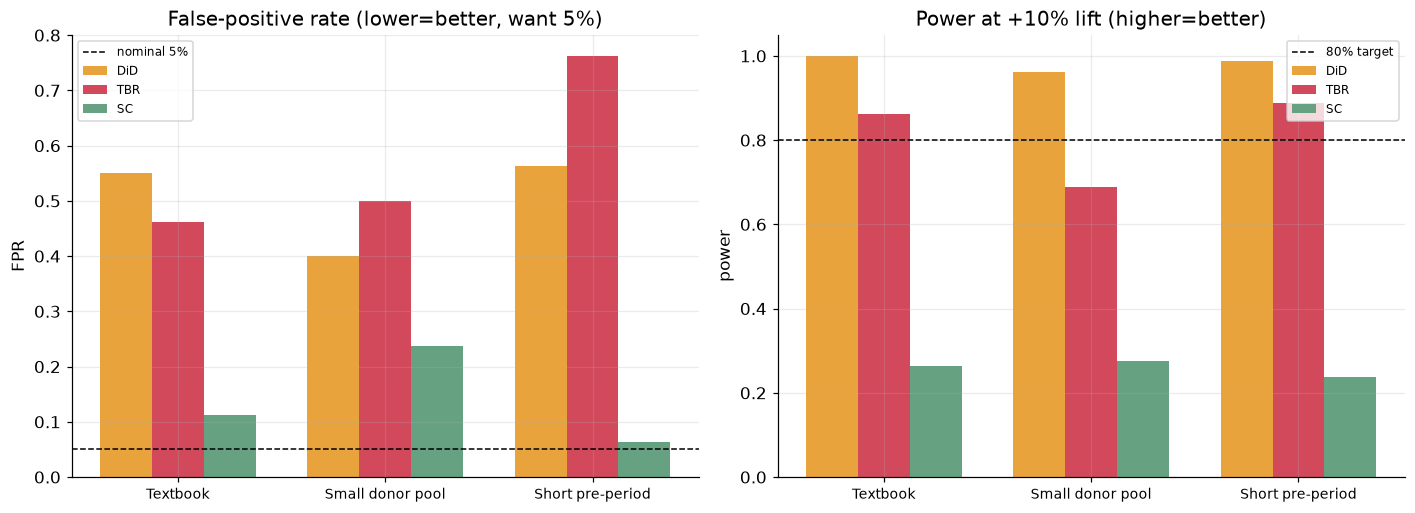

In [7]:
scns=list(SCENARIOS); tools=["DiD","TBR","SC"]
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.8)); x=np.arange(len(scns)); w=.25
for i,nm in enumerate(tools):
    fpr=[res[(res.scenario==s)&(res.tool==nm)&(res.tau==0)].reject.mean() for s in scns]
    pwr=[res[(res.scenario==s)&(res.tool==nm)&(res.tau==0.10)].reject.mean() for s in scns]
    a1.bar(x+(i-1)*w, fpr, w, color=TOOLCOL[nm], label=nm)
    a2.bar(x+(i-1)*w, pwr, w, color=TOOLCOL[nm], label=nm)
a1.axhline(.05,color="k",ls="--",lw=1,label="nominal 5%"); a1.set_title("False-positive rate (lower=better, want 5%)")
a1.set_xticks(x); a1.set_xticklabels(scns,fontsize=9); a1.set_ylabel("FPR"); a1.legend(fontsize=8)
a2.axhline(.8,color="k",ls="--",lw=1,label="80% target"); a2.set_title("Power at +10% lift (higher=better)")
a2.set_xticks(x); a2.set_xticklabels(scns,fontsize=9); a2.set_ylabel("power"); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

### The calibration trade-off — no tool dominates

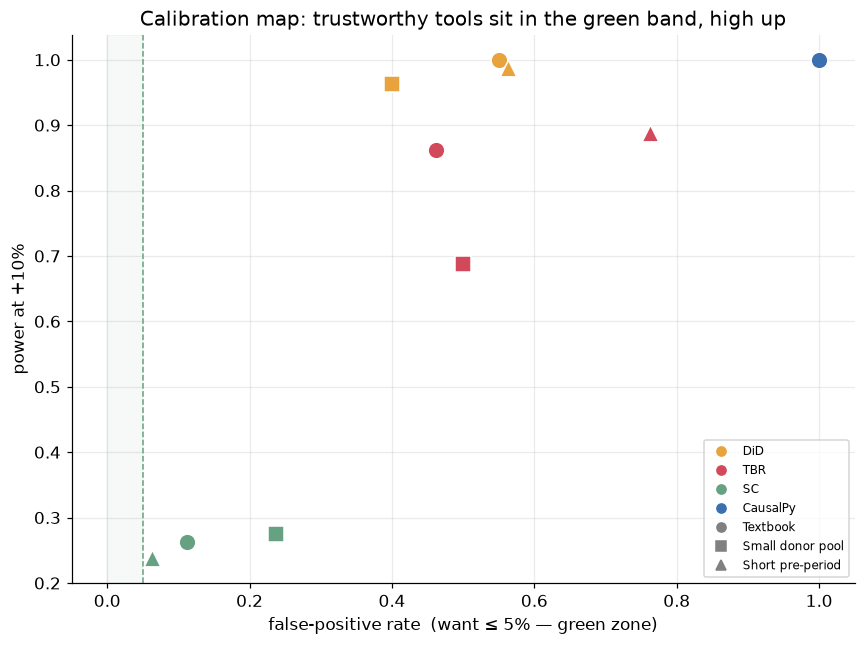

In [8]:
fig,ax=plt.subplots(figsize=(8,6))
for nm in ["DiD","TBR","SC","CausalPy"]:
    for s in scns:
        g0=res[(res.scenario==s)&(res.tool==nm)&(res.tau==0)]; g1=res[(res.scenario==s)&(res.tool==nm)&(res.tau==0.10)]
        if len(g0)==0: continue
        ax.scatter(g0.reject.mean(), g1.reject.mean(), s=120, color=TOOLCOL[nm],
                   marker={"Textbook":"o","Small donor pool":"s","Short pre-period":"^"}[s],
                   edgecolor="white", zorder=3)
ax.axvline(.05,color=GREEN,ls="--",lw=1); ax.axvspan(0,.05,color=GREEN,alpha=.06)
ax.set_xlabel("false-positive rate  (want ≤ 5% — green zone)"); ax.set_ylabel("power at +10%")
ax.set_title("Calibration map: trustworthy tools sit in the green band, high up")
from matplotlib.lines import Line2D
leg1=[Line2D([0],[0],marker="o",ls="",color=TOOLCOL[t],label=t) for t in ["DiD","TBR","SC","CausalPy"]]
leg2=[Line2D([0],[0],marker=m,ls="",color="grey",label=s) for s,m in
      [("Textbook","o"),("Small donor pool","s"),("Short pre-period","^")]]
ax.legend(handles=leg1+leg2,fontsize=8,loc="lower right")
plt.tight_layout(); plt.show()

## 6 · Conclusions

- **Geo-lift tools are not interchangeable** — same data, very different verdicts. The
  split is driven by **inference**, not the point estimate (all roughly recover +10%).
- **Analytic-SE tools over-reject.** DiD (cluster-robust with a single treated geo) and
  TBR (Gaussian PI ignoring AR(1) autocorrelation) post **false-positive rates far above
  5%** — they "find" lift that isn't there. Dangerous for go/no-go ad decisions.
- **Design-based inference is honest but can be underpowered.** SC's placebo inference
  roughly holds its level (FPR ~5–11%, coverage ~90%) at the cost of **power** — it misses
  real lifts unless the effect or the donor pool is large.
- **Bayesian ≠ automatically calibrated.** Read naively (a 95% credible interval on the
  *latent* cumulative impact, plus few iterations), CausalPy here was badly **over-confident**
  — near-100% false positives, ~8% coverage. The fix is to judge significance against the
  **posterior-predictive** counterfactual (which includes observation noise) and to set
  sensible priors. Lesson: validate calibration for *your* setup before trusting any tool.
- **Stress makes it worse.** Small donor pools and short pre-periods degrade every tool,
  but unevenly — exactly Recast's finding.

**For the label:** match the tool to the test. Use a **well-calibrated** estimator (SC/
GeoLift/CausalPy) for go/no-go incrementality calls, **design for power** up front (enough
control geos, long pre-period, big enough spend), and never trust a single naive p-value.

The companion document `FOUNDATIONS.md` catalogs every method, library, and reference used
across iterations 3–5.
